In [1]:
import matplotlib
print(matplotlib.get_backend())

import matplotlib.pyplot as plt
import os
import mmap
import struct
import time
import numpy as np


module://matplotlib_inline.backend_inline


In [95]:
# Definición de constantes
S2MM_CONTROL_REGISTER = 0x30
S2MM_STATUS_REGISTER = 0x34
S2MM_DST_ADDRESS_REGISTER = 0x48
S2MM_BUFF_LENGTH_REGISTER = 0x58

IOC_IRQ_FLAG = 1 << 12
IDLE_FLAG = 1 << 1

RESET_DMA = 0x00000004
HALT_DMA = 0x00000000
RUN_DMA = 0x00000001
ENABLE_ALL_IRQ = 0x00007000

DMA_BASE_ADDR = 0x80010000  # Dirección base del DMA AXI Lite
DST_BASE_ADDR = 0x0f000000  # Dirección base destino de memoria
DMA_MAP_SIZE = 65536
DST_MAP_SIZE = 8192 * 4

In [80]:
# Función para escribir en el DMA
def write_dma(mm, offset, value):
    mm[offset:offset+4] = struct.pack('<I', value)

# Función para leer desde el DMA
def read_dma(mm, offset):
    return struct.unpack('<I', mm[offset:offset+4])[0]

In [81]:
# Imprimir el estado del DMA
def dma_s2mm_status(mm):
    status = read_dma(mm, S2MM_STATUS_REGISTER)
    print(f"Stream to memory-mapped status (0x{status:08X}):")
    if status & 0x1:
        print("  Halted.")
    if status & IDLE_FLAG:
        print("  Idle.")
    if status & IOC_IRQ_FLAG:
        print("  IOC interrupt occurred.")
    print()

In [82]:
# Sincronización del DMA
def dma_s2mm_sync(mm):
    counter = 0
    while True:
        status = read_dma(mm, S2MM_STATUS_REGISTER)
        if (status & IOC_IRQ_FLAG) and (status & IDLE_FLAG):
            break
        dma_s2mm_status(mm)
        time.sleep(0.1)  # Agregar un pequeño retraso
        counter += 1
        if counter >= 5:  # Tiempo de espera máximo
            print("Timeout esperando sincronización del DMA.")
            break

In [83]:
# Imprimir datos en memoria
def print_mem(mm, byte_count):
    for i in range(byte_count):
        print(f"{mm[i]:02X}", end="")
        if i % 4 == 3:
            print(" ", end="")
    print()

In [84]:
# Programa principal
def main():
    print("Hello World! - Running DMA transfer test application.")

    # Abrir /dev/mem
    with open("/dev/mem", "r+b") as f:
        # Mapear la memoria del DMA
        dma_mm = mmap.mmap(f.fileno(), DMA_MAP_SIZE, offset=DMA_BASE_ADDR)
        dst_mm = mmap.mmap(f.fileno(), DST_MAP_SIZE, offset=DST_BASE_ADDR)

        print("Destination memory block data:")
        # print_mem(dst_mm, DST_MAP_SIZE)

        print("Resetting the DMA...")
        write_dma(dma_mm, S2MM_CONTROL_REGISTER, RESET_DMA)
        dma_s2mm_status(dma_mm)

        print("Halting the DMA...")
        write_dma(dma_mm, S2MM_CONTROL_REGISTER, HALT_DMA)
        dma_s2mm_status(dma_mm)

        print("Enabling all interrupts...")
        write_dma(dma_mm, S2MM_CONTROL_REGISTER, ENABLE_ALL_IRQ)
        dma_s2mm_status(dma_mm)

        print("Writing the destination address...")
        write_dma(dma_mm, S2MM_DST_ADDRESS_REGISTER, DST_BASE_ADDR)
        dma_s2mm_status(dma_mm)

        print("Running the S2MM channel...")
        write_dma(dma_mm, S2MM_CONTROL_REGISTER, RUN_DMA)
        dma_s2mm_status(dma_mm)

        print("Writing S2MM transfer length of 8192 bytes...")
        write_dma(dma_mm, S2MM_BUFF_LENGTH_REGISTER, DST_MAP_SIZE)
        dma_s2mm_status(dma_mm)

        print("Waiting for S2MM synchronization...")
        dma_s2mm_sync(dma_mm)

        print("Final DMA status:")
        dma_s2mm_status(dma_mm)

        print("Destination memory block data:")
        # print_mem(dst_mm, DST_MAP_SIZE)

        # Cerrar los mapeos
        #dma_mm.close()
        #dst_mm.close()


In [85]:
main()

Hello World! - Running DMA transfer test application.
Destination memory block data:
Resetting the DMA...
Stream to memory-mapped status (0x00000001):
  Halted.

Halting the DMA...
Stream to memory-mapped status (0x00000001):
  Halted.

Enabling all interrupts...
Stream to memory-mapped status (0x00000001):
  Halted.

Writing the destination address...
Stream to memory-mapped status (0x00000001):
  Halted.

Running the S2MM channel...
Stream to memory-mapped status (0x00000000):

Writing S2MM transfer length of 8192 bytes...
Stream to memory-mapped status (0x00000000):

Waiting for S2MM synchronization...
Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.

Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.

Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.

Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.

Stream to memory-mapped status (0x00005011):
  Halted.
  IO

In [86]:
def get_mem_data(mm, byte_count):
    num_elements = byte_count // 4  # El número de elementos de 4 bytes (32 bits)
    delay = 8
    data = np.zeros(num_elements-delay, dtype=np.uint32)  # Crear un array de ceros de tipo uint32
    for i in range(delay,num_elements):
        # Leer 4 bytes y almacenarlos como un entero de 32 bits (uint32)
        data[i-delay] = struct.unpack('<I', mm[i*4:i*4+4])[0]
    return data

In [87]:
def plot_mem_data(data):
    # Graficar los datos y su derivada
    derivative = np.diff(data)  # np.diff calcula la diferencia entre elementos consecutivos
    
    plt.figure(figsize=(10, 6))

    # Graficar los datos originales
    plt.subplot(2, 1, 1)
    plt.plot(data, label="Datos Originales")
    plt.title("Señal Original")
    plt.xlabel("Índice")
    plt.ylabel("Valor de la Señal")
    plt.grid(True)
    plt.legend()
    #plt.xlim([1000,7000])
    #plt.ylim([data[1000],data[7000]])
    #plt.show()
    
     # Graficar la derivada
    plt.subplot(2, 1, 2)
    plt.plot(derivative, label="Derivada", color='red')
    plt.title("Derivada de la Señal")
    plt.xlabel("Índice")
    plt.ylabel("Valor de la Derivada")
    plt.grid(True)
    plt.legend()

In [96]:
f = open("/dev/mem", "r+b")
    
# Mapear la memoria del DMA
dma_mm = mmap.mmap(f.fileno(), DMA_MAP_SIZE, offset=DMA_BASE_ADDR)
dst_mm = mmap.mmap(f.fileno(), DST_MAP_SIZE, offset=DST_BASE_ADDR)


In [41]:
print("Destination memory block data:")
print_mem(dst_mm, DST_MAP_SIZE)

Destination memory block data:


CA000000 CC000000 CE000000 D0000000 AC0E0000 AE0E0000 B00E0000 B20E0000 B40E0000 B60E0000 B80E0000 BA0E0000 BC0E0000 BE0E0000 C00E0000 C20E0000 C40E0000 C60E0000 C80E0000 CA0E0000 CC0E0000 CE0E0000 D00E0000 D20E0000 D40E0000 D60E0000 D80E0000 DA0E0000 DC0E0000 DE0E0000 E00E0000 E20E0000 E40E0000 E60E0000 E80E0000 EA0E0000 EC0E0000 EE0E0000 F00E0000 F20E0000 F40E0000 F60E0000 F80E0000 FA0E0000 FC0E0000 FE0E0000 000F0000 020F0000 040F0000 060F0000 080F0000 0A0F0000 0C0F0000 0E0F0000 100F0000 120F0000 140F0000 160F0000 180F0000 1A0F0000 1C0F0000 1E0F0000 200F0000 220F0000 240F0000 260F0000 280F0000 2A0F0000 2C0F0000 2E0F0000 300F0000 320F0000 340F0000 360F0000 380F0000 3A0F0000 3C0F0000 3E0F0000 400F0000 420F0000 440F0000 460F0000 480F0000 4A0F0000 4C0F0000 4E0F0000 500F0000 520F0000 540F0000 560F0000 580F0000 5A0F0000 5C0F0000 5E0F0000 600F0000 620F0000 640F0000 660F0000 680F0000 6A0F0000 6C0F0000 6E0F0000 700F0000 720F0000 740F0000 760F0000 780F0000 7A0F0000 7C0F0000 7E0F0000 800F0000 8

040000 4E040000 50040000 52040000 54040000 56040000 58040000 5A040000 5C040000 5E040000 60040000 62040000 64040000 66040000 68040000 6A040000 6C040000 6E040000 70040000 72040000 74040000 76040000 78040000 7A040000 7C040000 7E040000 80040000 82040000 84040000 86040000 88040000 8A040000 8C040000 8E040000 90040000 92040000 94040000 96040000 98040000 9A040000 9C040000 9E040000 A0040000 A2040000 A4040000 A6040000 A8040000 AA040000 AC040000 AE040000 B0040000 B2040000 B4040000 B6040000 B8040000 BA040000 BC040000 BE040000 C0040000 C2040000 C4040000 C6040000 C8040000 CA040000 CC040000 CE040000 D0040000 D2040000 D4040000 D6040000 D8040000 DA040000 DC040000 DE040000 E0040000 E2040000 E4040000 E6040000 E8040000 EA040000 EC040000 EE040000 F0040000 F2040000 F4040000 F6040000 F8040000 FA040000 FC040000 FE040000 00050000 02050000 04050000 06050000 08050000 0A050000 0C050000 0E050000 10050000 12050000 14050000 16050000 18050000 1A050000 1C050000 1E050000 20050000 22050000 24050000 26050000 28050000 2A0

00 C00B0000 C20B0000 C40B0000 C60B0000 C80B0000 CA0B0000 CC0B0000 CE0B0000 D00B0000 D20B0000 D40B0000 D60B0000 D80B0000 DA0B0000 DC0B0000 DE0B0000 E00B0000 E20B0000 E40B0000 E60B0000 E80B0000 EA0B0000 EC0B0000 EE0B0000 F00B0000 F20B0000 F40B0000 F60B0000 F80B0000 FA0B0000 FC0B0000 FE0B0000 000C0000 020C0000 040C0000 060C0000 080C0000 0A0C0000 0C0C0000 0E0C0000 100C0000 120C0000 140C0000 160C0000 180C0000 1A0C0000 1C0C0000 1E0C0000 200C0000 220C0000 240C0000 260C0000 280C0000 2A0C0000 2C0C0000 2E0C0000 300C0000 320C0000 340C0000 360C0000 380C0000 3A0C0000 3C0C0000 3E0C0000 400C0000 420C0000 440C0000 460C0000 480C0000 4A0C0000 4C0C0000 4E0C0000 500C0000 520C0000 540C0000 560C0000 580C0000 5A0C0000 5C0C0000 5E0C0000 600C0000 620C0000 640C0000 660C0000 680C0000 6A0C0000 6C0C0000 6E0C0000 700C0000 720C0000 740C0000 760C0000 780C0000 7A0C0000 7C0C0000 7E0C0000 800C0000 820C0000 840C0000 860C0000 880C0000 8A0C0000 8C0C0000 8E0C0000 900C0000 920C0000 940C0000 960C0000 980C0000 9A0C0000 9C0C000

000000 E0000000 E2000000 E4000000 E6000000 E8000000 EA000000 EC000000 EE000000 F0000000 F2000000 F4000000 F6000000 F8000000 FA000000 FC000000 FE000000 00010000 02010000 04010000 06010000 08010000 0A010000 0C010000 0E010000 10010000 12010000 14010000 16010000 18010000 1A010000 1C010000 1E010000 20010000 22010000 24010000 26010000 28010000 2A010000 2C010000 2E010000 30010000 32010000 34010000 36010000 38010000 3A010000 3C010000 3E010000 40010000 42010000 44010000 46010000 48010000 4A010000 4C010000 4E010000 50010000 52010000 54010000 56010000 58010000 5A010000 5C010000 5E010000 60010000 62010000 64010000 66010000 68010000 6A010000 6C010000 6E010000 70010000 72010000 74010000 76010000 78010000 7A010000 7C010000 7E010000 80010000 82010000 84010000 86010000 88010000 8A010000 8C010000 8E010000 90010000 92010000 94010000 96010000 98010000 9A010000 9C010000 9E010000 A0010000 A2010000 A4010000 A6010000 A8010000 AA010000 AC010000 AE010000 B0010000 B2010000 B4010000 B6010000 B8010000 BA010000 BC0

080000 5A080000 5C080000 5E080000 60080000 62080000 64080000 66080000 68080000 6A080000 6C080000 6E080000 70080000 72080000 74080000 76080000 78080000 7A080000 7C080000 7E080000 80080000 82080000 84080000 86080000 88080000 8A080000 8C080000 8E080000 90080000 92080000 94080000 96080000 98080000 9A080000 9C080000 9E080000 A0080000 A2080000 A4080000 A6080000 A8080000 AA080000 AC080000 AE080000 B0080000 B2080000 B4080000 B6080000 B8080000 BA080000 BC080000 BE080000 C0080000 C2080000 C4080000 C6080000 C8080000 CA080000 CC080000 CE080000 D0080000 D2080000 D4080000 D6080000 D8080000 DA080000 DC080000 DE080000 E0080000 E2080000 E4080000 E6080000 E8080000 EA080000 EC080000 EE080000 F0080000 F2080000 F4080000 F6080000 F8080000 FA080000 FC080000 FE080000 00090000 02090000 04090000 06090000 08090000 0A090000 0C090000 0E090000 10090000 12090000 14090000 16090000 18090000 1A090000 1C090000 1E090000 20090000 22090000 24090000 26090000 28090000 2A090000 2C090000 2E090000 30090000 32090000 34090000 360

0F0000 CA0F0000 CC0F0000 CE0F0000 D00F0000 D20F0000 D40F0000 D60F0000 D80F0000 DA0F0000 DC0F0000 DE0F0000 E00F0000 E20F0000 E40F0000 E60F0000 E80F0000 EA0F0000 EC0F0000 EE0F0000 F00F0000 F20F0000 F40F0000 F60F0000 F80F0000 FA0F0000 FC0F0000 FE0F0000 00100000 02100000 04100000 06100000 08100000 0A100000 0C100000 0E100000 10100000 12100000 14100000 16100000 18100000 1A100000 1C100000 1E100000 20100000 22100000 24100000 26100000 28100000 2A100000 2C100000 2E100000 30100000 32100000 34100000 36100000 38100000 3A100000 3C100000 3E100000 40100000 42100000 44100000 46100000 48100000 4A100000 4C100000 4E100000 50100000 52100000 54100000 56100000 58100000 5A100000 5C100000 5E100000 60100000 62100000 64100000 66100000 68100000 6A100000 6C100000 6E100000 70100000 72100000 74100000 76100000 78100000 7A100000 7C100000 7E100000 80100000 82100000 84100000 86100000 88100000 8A100000 8C100000 8E100000 90100000 92100000 94100000 96100000 98100000 9A100000 9C100000 9E100000 A0100000 A2100000 A4100000 A61

040000 EC040000 EE040000 F0040000 F2040000 F4040000 F6040000 F8040000 FA040000 FC040000 FE040000 00050000 02050000 04050000 06050000 08050000 0A050000 0C050000 0E050000 10050000 12050000 14050000 16050000 18050000 1A050000 1C050000 1E050000 20050000 22050000 24050000 26050000 28050000 2A050000 2C050000 2E050000 30050000 32050000 34050000 36050000 38050000 3A050000 3C050000 3E050000 40050000 42050000 44050000 46050000 48050000 4A050000 4C050000 4E050000 50050000 52050000 54050000 56050000 58050000 5A050000 5C050000 5E050000 60050000 62050000 64050000 66050000 68050000 6A050000 6C050000 6E050000 70050000 72050000 74050000 76050000 78050000 7A050000 7C050000 7E050000 80050000 82050000 84050000 86050000 88050000 8A050000 8C050000 8E050000 90050000 92050000 94050000 96050000 98050000 9A050000 9C050000 9E050000 A0050000 A2050000 A4050000 A6050000 A8050000 AA050000 AC050000 AE050000 B0050000 B2050000 B4050000 B6050000 B8050000 BA050000 BC050000 BE050000 C0050000 C2050000 C4050000 C6050000 C80

 5A0C0000 5C0C0000 5E0C0000 600C0000 620C0000 640C0000 660C0000 680C0000 6A0C0000 6C0C0000 6E0C0000 700C0000 720C0000 740C0000 760C0000 780C0000 7A0C0000 7C0C0000 7E0C0000 800C0000 820C0000 840C0000 860C0000 880C0000 8A0C0000 8C0C0000 8E0C0000 900C0000 920C0000 940C0000 960C0000 980C0000 9A0C0000 9C0C0000 9E0C0000 A00C0000 A20C0000 A40C0000 A60C0000 A80C0000 AA0C0000 AC0C0000 AE0C0000 B00C0000 B20C0000 B40C0000 B60C0000 B80C0000 BA0C0000 BC0C0000 BE0C0000 C00C0000 C20C0000 C40C0000 C60C0000 C80C0000 CA0C0000 CC0C0000 CE0C0000 D00C0000 D20C0000 D40C0000 D60C0000 D80C0000 DA0C0000 DC0C0000 DE0C0000 E00C0000 E20C0000 E40C0000 E60C0000 E80C0000 EA0C0000 EC0C0000 EE0C0000 F00C0000 F20C0000 F40C0000 F60C0000 F80C0000 FA0C0000 FC0C0000 FE0C0000 000D0000 020D0000 040D0000 060D0000 080D0000 0A0D0000 0C0D0000 0E0D0000 100D0000 120D0000 140D0000 160D0000 180D0000 1A0D0000 1C0D0000 1E0D0000 200D0000 220D0000 240D0000 260D0000 280D0000 2A0D0000 2C0D0000 2E0D0000 300D0000 320D0000 340D0000 360D0000 

 7A010000 7C010000 7E010000 80010000 82010000 84010000 86010000 88010000 8A010000 8C010000 8E010000 90010000 92010000 94010000 96010000 98010000 9A010000 9C010000 9E010000 A0010000 A2010000 A4010000 A6010000 A8010000 AA010000 AC010000 AE010000 B0010000 B2010000 B4010000 B6010000 B8010000 BA010000 BC010000 BE010000 C0010000 C2010000 C4010000 C6010000 C8010000 CA010000 CC010000 CE010000 D0010000 D2010000 D4010000 D6010000 D8010000 DA010000 DC010000 DE010000 E0010000 E2010000 E4010000 E6010000 E8010000 EA010000 EC010000 EE010000 F0010000 F2010000 F4010000 F6010000 F8010000 FA010000 FC010000 FE010000 00020000 02020000 04020000 06020000 08020000 0A020000 0C020000 0E020000 10020000 12020000 14020000 16020000 18020000 1A020000 1C020000 1E020000 20020000 22020000 24020000 26020000 28020000 2A020000 2C020000 2E020000 30020000 32020000 34020000 36020000 38020000 3A020000 3C020000 3E020000 40020000 42020000 44020000 46020000 48020000 4A020000 4C020000 4E020000 50020000 52020000 54020000 56020000 

In [97]:
print("Resetting the DMA...")
write_dma(dma_mm, S2MM_CONTROL_REGISTER, RESET_DMA)
dma_s2mm_status(dma_mm)

print("Halting the DMA...")
write_dma(dma_mm, S2MM_CONTROL_REGISTER, HALT_DMA)
dma_s2mm_status(dma_mm)

print("Enabling all interrupts...")
write_dma(dma_mm, S2MM_CONTROL_REGISTER, ENABLE_ALL_IRQ)
dma_s2mm_status(dma_mm)

print("Writing the destination address...")
write_dma(dma_mm, S2MM_DST_ADDRESS_REGISTER, DST_BASE_ADDR)
dma_s2mm_status(dma_mm)

print("Running the S2MM channel...")
write_dma(dma_mm, S2MM_CONTROL_REGISTER, RUN_DMA)
dma_s2mm_status(dma_mm)

print("Writing S2MM transfer length of 8192 bytes...")
write_dma(dma_mm, S2MM_BUFF_LENGTH_REGISTER, DST_MAP_SIZE)
dma_s2mm_status(dma_mm)

print("Waiting for S2MM synchronization...")
dma_s2mm_sync(dma_mm)

print("Final DMA status:")
dma_s2mm_status(dma_mm)

Resetting the DMA...
Stream to memory-mapped status (0x00000001):
  Halted.

Halting the DMA...
Stream to memory-mapped status (0x00000001):
  Halted.

Enabling all interrupts...
Stream to memory-mapped status (0x00000001):
  Halted.

Writing the destination address...
Stream to memory-mapped status (0x00000001):
  Halted.

Running the S2MM channel...
Stream to memory-mapped status (0x00000000):

Writing S2MM transfer length of 8192 bytes...
Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.

Waiting for S2MM synchronization...
Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.

Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.

Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.

Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.

Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.

Timeout esperando sincroni

In [15]:
print("Destination memory block data:")
print_mem(dst_mm, DST_MAP_SIZE)

Destination memory block data:


00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 0

0000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000

0000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000

0000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000

 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 

 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 

00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 0

00 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 0000000

00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 00000000 0

In [98]:
data = get_mem_data(dst_mm, DST_MAP_SIZE)

In [99]:
print(data[0:30])

[1570 1572 1574 1576 1578 1580 1582 1584 1586 1588 1590 1592 1594 1596
 1598 1600 1602 1604 1606 1608 1610 1612 1614 1616 1618 1620 1622 1624
 1626 1628]


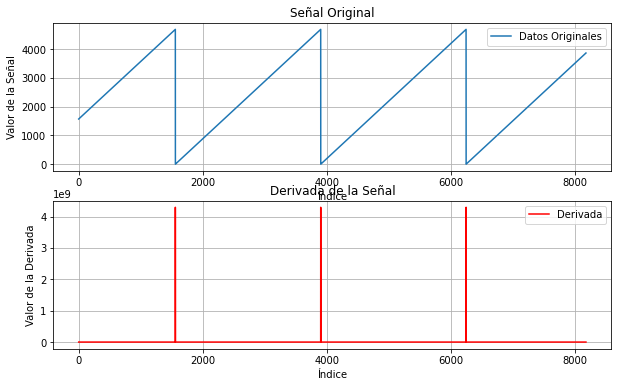

In [100]:
plot_mem_data(data)

(2000.0, 2500.0)

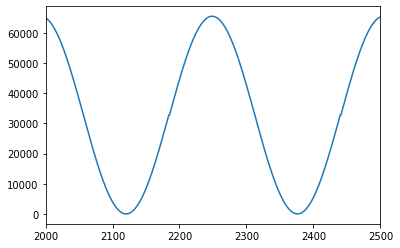

In [93]:
plt.plot(data)
plt.xlim([2000, 2500])

(2000.0, 2500.0)

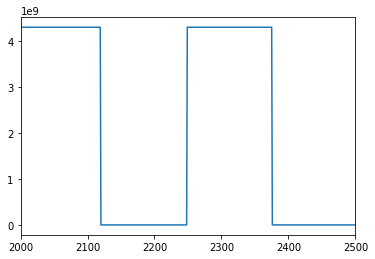

In [94]:
plt.plot(np.diff(data))
plt.xlim([2000, 2500])